# CNN Mel Spectrogram on GTZAN Dataset

## Imports & Macros

In [1]:
import os
import librosa as lr
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.image import resize

2026-03-27 00:19:51.935529: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 00:19:52.049801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774559992.091689    9223 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774559992.104461    9223 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774559992.206420    9223 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
#Constants
FMA_FOLDER_PATH = "data/fma_small/"
GTZAN_FOLDER_PATH = "data/gtzan/genres/"
FS = 22050
TARGET_DURATION = 30
TOTAL_SAMPLES = FS * TARGET_DURATION

## Utility Functions 

In [8]:
def fma_row_to_file_path(row):
    track_id = row["track_id"]
    return os.path.join(FMA_FOLDER_PATH, f"{track_id//1000:03d}", f"{track_id:06d}.mp3")

def gtzan_row_to_file_path(row):
    genre = row["genre_name"]
    track_id = row["track_id"]
    return os.path.join(GTZAN_FOLDER_PATH, genre, f"{genre}.{track_id:05d}.au")

## Dataset Preparation For GTZAN 

### Visualize Audio

/home/rosgeek/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


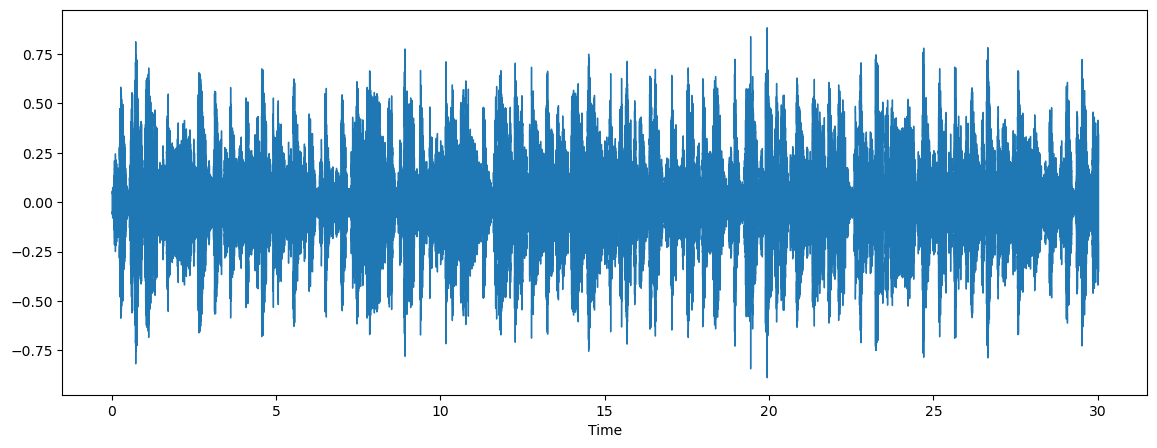

In [3]:
file_path = "data/gtzan/genres/blues/blues.00000.au"
y, sr = lr.load(file_path)
plt.figure(figsize=(14,5))
lr.display.waveshow(y,sr=sr)

In [4]:
y.shape

(661794,)

In [ ]:
y, sr = lr.load(file_path, sr=None)  # sr=None to keep the original sampling rate

# Define the duration of each chunk and overlap
chunk_duration = 4  # seconds
overlap_duration = 2  # seconds

# Convert durations to samples
chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr

# Calculate the number of chunks
num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

# Iterate over each chunk
for i in range(num_chunks):
    # Calculate start and end indices of the chunk
    start = i * (chunk_samples - overlap_samples)
    end = start + chunk_samples
    
    # Extract the chunk of audio
    chunk = y[start:end]
    plt.figure(figsize=(4, 2))
    lr.display.waveshow(chunk, sr=sr)
    plt.show()

## Mel Spectrogram Visualization

In [6]:
#Plotting Melspectrogram of Entire Audio
def plot_melspectrogram(y,sr):
    #Compute spectrogram
    spectrogram = lr.feature.melspectrogram(y=y,sr=sr)
    #Convert to decibels (log scale)
    spectrogram_db = lr.power_to_db(spectrogram,ref=np.max)
    #Visualize the spectrogram
    plt.figure(figsize=(10,4))
    lr.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
    plt.colorbar(format='%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()

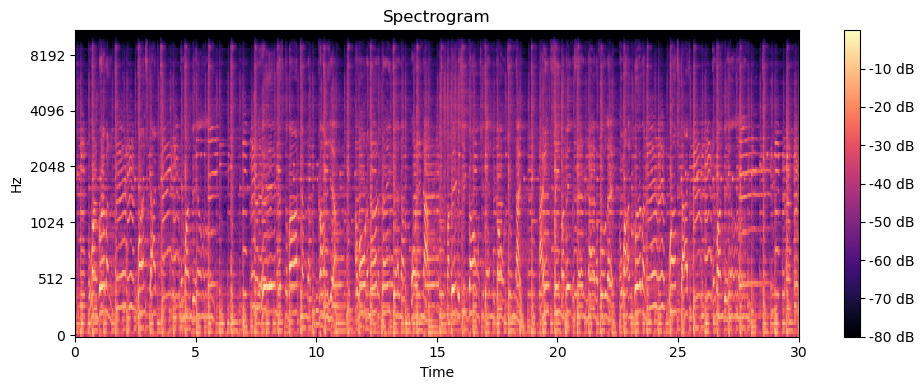

In [7]:
y,sr = lr.load(file_path)
plot_melspectrogram(y,sr)

In [8]:
def plot_melspectrogram_chunks(y,sr):
    #define the duration of each chunk and overlap
    chunk_duration = 4
    overlap_duration = 2
    
    #Convert duration to sample
    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr
    
    #Calculate the number of chunks
    num_chunks = int(np.ceil((len(y)-chunk_samples)/(chunk_samples-overlap_samples)))+1
    
    #iterate over each chunks
    for i in range(num_chunks):
        #Calculate start and end indices of the chunk
        start = i*(chunk_samples-overlap_samples)
        end = start+chunk_samples
        #Extract the chunk audio
        chunk = y[start:end]
        #Melspectrogram part
        spectrogram = lr.feature.melspectrogram(y=chunk,sr=sr)
        print(spectrogram.shape)
        spectrogram_db = lr.power_to_db(spectrogram,ref=np.max)
        #Visualize the spectrogram
        plt.figure(figsize=(10,4))
        lr.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
        plt.colorbar(format='%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()

In [ ]:
y,sr = lr.load(file_path,sr=44100)
plot_melspectrogram_chunks(y,sr)

## Dataset Creation For Mel Spectrograms -- GTZAN Dataset

In [5]:
CHUNK_DURATION = 3.0
OVERLAP_DURATION = 1.5
gtzan_tracks = pd.read_csv("data/gtzan_tracks.csv")

In [10]:
def load_gtzan_mel_spec_data(gtzan_tracks, chunk_duration, overlap_duration, audio_duration, sr=22050, hop_length=512, n_mels=128):
    num_samples = int(audio_duration * sr)
    chunk_samples = int(chunk_duration * sr)
    stride = chunk_samples - int(overlap_duration * sr)
    num_chunks = int((num_samples - chunk_samples) // stride) + 1
    n_frames = (chunk_samples // hop_length) + 1
    
    set_size = len(gtzan_tracks)
    total_chunks = set_size * num_chunks
    
    # Pre-allocate flattened arrays to avoid indexing/reshaping errors
    X = np.zeros((total_chunks, n_mels, n_frames), dtype=np.float32)
    y = np.zeros((total_chunks,), dtype=np.int32)

    # Use enumerate to get a safe, sequential write index
    for track_idx, (index, row) in enumerate(gtzan_tracks.iterrows()):
        audio_path = gtzan_row_to_file_path(row)
        audio_data, _ = lr.load(audio_path, sr=sr, duration=audio_duration)
        
        # Ensure consistent length
        if len(audio_data) < num_samples:
            audio_data = np.pad(audio_data, (0, num_samples - len(audio_data)))
        else:
            audio_data = audio_data[:num_samples]

        for i in range(num_chunks):
            start = i * stride
            end = start + chunk_samples
            chunk = audio_data[start:end]
            
            mel_spec = lr.feature.melspectrogram(y=chunk, sr=sr, hop_length=hop_length, n_mels=n_mels)
            
            # CRITICAL FIX: Convert to decibels
            log_mel_spec = lr.power_to_db(mel_spec, ref=np.max)
            
            # Map chunk back to label accurately
            write_pos = (track_idx * num_chunks) + i
            X[write_pos] = log_mel_spec
            y[write_pos] = row["genre_id"]
            
    return X, y

## Load the Dataset

In [11]:
dataset, labels = load_gtzan_mel_spec_data(gtzan_tracks, chunk_duration=CHUNK_DURATION, overlap_duration=OVERLAP_DURATION, audio_duration=30)
dataset = np.array(dataset, dtype=np.float32)
labels = np.array(labels)
print(dataset.shape, labels.shape)

/home/rosgeek/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(19000, 128, 130) (19000,)


## One Hot Encoding the Class Labels

In [12]:
labels = tf.keras.utils.to_categorical(labels, num_classes=10)
labels.shape

(19000, 10)

In [13]:
labels[:2]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

## Standardized Dataset Scaling 

In [14]:
dataset_min, dataset_max = dataset.min(), dataset.max()
dataset = (dataset - dataset_min) / (dataset_max - dataset_min)

In [15]:
X = dataset[:, :, :, np.newaxis]
X.shape

(19000, 128, 130, 1)

## Train/Test Split

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
X_train,X_test,Y_train,Y_test = train_test_split(X, labels, test_size=0.2,random_state=42)

X_train, Y_train = shuffle(X_train, Y_train, random_state=42)
X_test, Y_test = shuffle(X_test, Y_test, random_state=42)

## Build the Model for Mel Spectrograms

In [17]:
def build_model(input_shape=(128,130,1)):
        # build network topology
    model = tf.keras.Sequential()

    # 1st conv layer
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())

    # 2nd conv layer
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())

    # 3rd conv layer
    model.add(tf.keras.layers.Conv2D(32, (2, 2), activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())

    # flatten output and feed it into dense layer
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu'))
    model.add(tf.keras.layers.Dropout(0.3))

    # output layer
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

In [18]:
model = build_model()
model.summary()

/home/rosgeek/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773399173.178528   19146 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4151 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 475,594 (1.81 MB)

 Trainable params: 475,402 (1.81 MB)

 Non-trainable params: 192 (768.00 B)

## Compile & Train the Model 

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,   # Cut the learning rate in half
    patience=10,  # If val_loss doesn't improve for 10 epochs
    min_lr=1e-5   # Don't let the learning rate go to absolute zero
)

In [ ]:
#Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy()
    ],
)

In [ ]:
history = model.fit(
    X_train, Y_train, batch_size=32, epochs=250, verbose="auto", validation_split=0.2, shuffle=True, callbacks=[reduce_lr]
)

Epoch 1/250
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - categorical_accuracy: 0.9869 - loss: 0.0418 - val_categorical_accuracy: 0.8434 - val_loss: 1.0877
Epoch 2/250
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - categorical_accuracy: 0.9866 - loss: 0.0371 - val_categorical_accuracy: 0.7961 - val_loss: 1.1391
Epoch 3/250
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - categorical_accuracy: 0.9854 - loss: 0.0400 - val_categorical_accuracy: 0.7480 - val_loss: 2.8991
Epoch 4/250
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - categorical_accuracy: 0.9848 - loss: 0.0437 - val_categorical_accuracy: 0.6970 - val_loss: 3.3610
Epoch 5/250
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - categorical_accuracy: 0.9860 - loss: 0.0503 - val_categorical_accuracy: 0.8375 - val_loss: 0.9265
Epoch 6/250
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - categorical_accuracy: 0.9869 - loss: 0.0404 - val_categorical_accuracy: 0.7783 - val_loss: 2.7837
Epoch 7/250
380/380 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - categorical_accuracy

## Save the Model & Training History

In [ ]:
import json
with open("models/gtzan/cnn_mel_spec/cnn_mel_spec_train_history.json", "w") as f:
    json.dump(history.history, f)

model.save("models/gtzan/cnn_mel_spec/cnn_mel_spec.h5")

## CNN Mel Spec GTZAN Training Performance Evaluation

In [19]:
import json
import matplotlib.pyplot as plt

def plot_training_history(history_file_path):
    try:
        with open(history_file_path, 'r') as f:
            history = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file at '{history_file_path}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: The file at '{history_file_path}' is not valid JSON.")
        return

    # Handle standard key variations between different TensorFlow versions
    categorical_accuracy = "categorical_accuracy" if "categorical_accuracy" in history else "categorical_acc"
    val_categorical_accuracy = "val_categorical_accuracy" if "val_categorical_accuracy" in history else "val_categorical_acc" 

    # Generate epoch numbers (1 to N)
    epochs = range(1, len(history['loss']) + 1)

    # 2. Set up the plotting canvas (1 row, 2 columns)
    plt.figure(figsize=(14, 5))

    # --- Plot 1: Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], label='Training Loss', color='teal', linewidth=2)
    
    if 'val_loss' in history:
        plt.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
        
    plt.title('Loss Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)

    # --- Plot 2: Accuracy ---
    plt.subplot(1, 2, 2)
    if categorical_accuracy in history:
        plt.plot(epochs, history['categorical_accuracy'], label='Training Accuracy', color='teal', linewidth=2)
    if val_categorical_accuracy in history:
        plt.plot(epochs, history['val_categorical_accuracy'], label='Validation Accuracy', color='orange', linewidth=2, linestyle="--")
        
    plt.title('Accuracy Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.7)

    # 3. Render the graphs
    plt.tight_layout()
    plt.show()

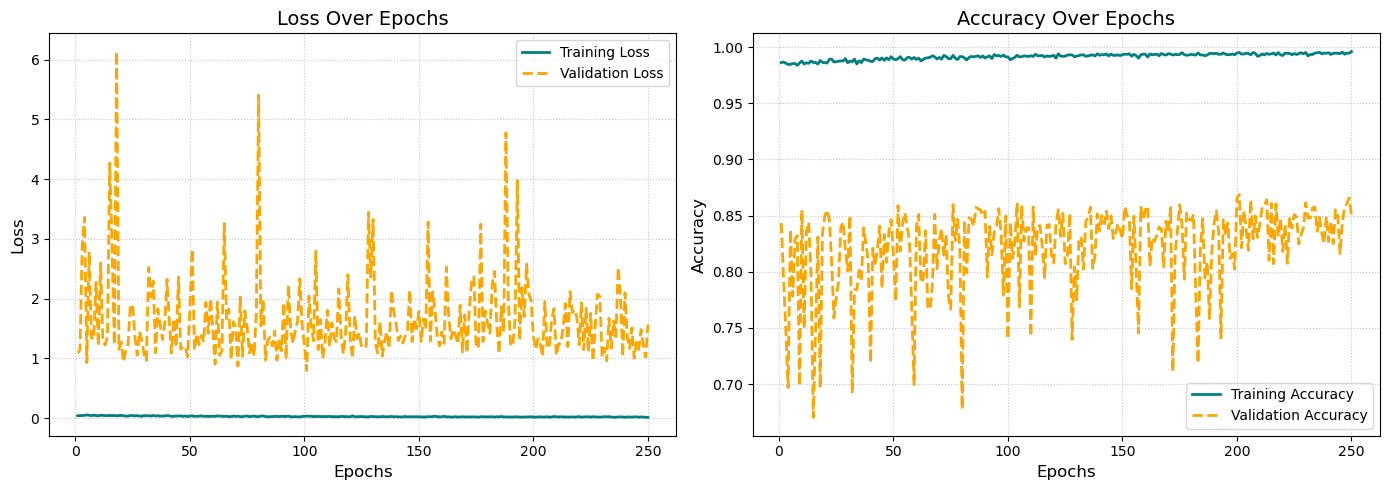

In [20]:
plot_training_history("models/gtzan/cnn_mel_spec/cnn_mel_spec_train_history.json")

## Test Set Model Performance

In [25]:
model = tf.keras.models.load_model("models/gtzan/cnn_mel_spec/cnn_mel_spec.h5")
loss, accuracy = model.evaluate(X_test, Y_test)

print(f"Test Set Model Loss: {loss:.6f}, Test Set Model Accuracy: {(accuracy * 100) :.6f}%")

119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - categorical_accuracy: 0.8538 - loss: 1.6299
Test Set Model Loss: 1.558223, Test Set Model Accuracy: 85.263157%
